# ISYE 6414 - Life Expectancy

## Introduction

The objective of this project is to identify which factors have the largest marginal association with life expectancy across countries. The analysis uses a country-year panel dataset constructed from three sources: the Human Development Index dataset, World Development Indicators, and World Health Organization data. The analysis focuses on regression modeling, exploratory data analysis, variable selection, diagnostics, validation, and interpretation of final model results.

## Data sources:
#### World Health Organization (WHO): 24,000+ observations from 2000-2021
#### World Development Indicators (WDI): 10,000+ observations from 2000-2025
#### UNDP (HDI): 1000+ observations, 206 countries from 1990-2023

___

## Loading Libraries

In [1]:
library(data.table)
library(dplyr)
library(tidyr)
library(MASS)
library(car)
library(lmtest)
library(sandwich)
library(ggplot2)
library(caret)
set.seed(100)


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select


Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:data.table':

    yearmon, yearqtr


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Loading required package: lattice



## Importing the Datasets and Basic Data Exploration

In [2]:
hdi_base <- read.csv("HDI Dataset.csv", header = TRUE)
wdi_base <- read.csv("WDI Dataset.csv", header = TRUE)
who_base <- read.csv("WHO Dataset.csv", header = TRUE)

names(hdi_base) <- tolower(names(hdi_base))
names(wdi_base) <- tolower(names(wdi_base))
names(who_base) <- tolower(names(who_base))

In [3]:
head(hdi_base)

,iso3,country,hdicode,region,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,⋯,pop_total_2014,pop_total_2015,pop_total_2016,pop_total_2017,pop_total_2018,pop_total_2019,pop_total_2020,pop_total_2021,pop_total_2022,pop_total_2023
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AFG,Afghanistan,Low,SA,181,0.285,0.291,0.301,0.311,0.305,⋯,32.792523,33.8317635,34.7006120,35.6889345,36.743039,37.8561210,39.068979,40.0004120,40.578842,41.4547610
2,ALB,Albania,Very High,ECA,71,0.654,0.638,0.622,0.624,0.629,⋯,2.903749,2.8986320,2.8978665,2.8982425,2.894231,2.8850095,2.871954,2.8496355,2.827608,2.8116550
3,DZA,Algeria,High,AS,96,0.595,0.596,0.601,0.603,0.603,⋯,39.205030,40.0195290,40.8507210,41.6892990,42.505035,43.2945460,44.042091,44.7610990,45.477390,46.1642190
4,AND,Andorra,Very High,,32,NA,NA,NA,NA,NA,⋯,0.073737,0.0721735,0.0721815,0.0737625,0.075162,0.0764735,0.077380,0.0783635,0.079705,0.0808560
5,AGO,Angola,Medium,SSA,148,NA,NA,NA,NA,NA,⋯,27.160770,28.1577980,29.1830700,30.2348390,31.297155,32.3756325,33.451132,34.5324290,35.635029,36.7499060
6,ATG,Antigua and Barbuda,Very High,LAC,53,NA,NA,NA,NA,NA,⋯,0.088765,0.0894090,0.0899690,0.0904680,0.090926,0.0913635,0.091846,0.0923490,0.092840,0.0933155


In [4]:
head(wdi_base)

,country.name,country.code,series.name,series.code,x2000..yr2000.,x2001..yr2001.,x2002..yr2002.,x2003..yr2003.,x2004..yr2004.,x2005..yr2005.,⋯,x2016..yr2016.,x2017..yr2017.,x2018..yr2018.,x2019..yr2019.,x2020..yr2020.,x2021..yr2021.,x2022..yr2022.,x2023..yr2023.,x2024..yr2024.,x2025..yr2025.
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,174.930991430166,138.706821676113,178.954088379235,198.871115728727,221.763653873013,254.184249149336,⋯,522.082215583898,525.469770891619,491.337221382603,496.6025042585,510.787063366811,356.496214115892,357.261152798144,413.757894705303,..,..
2,Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,..,-10.1194841059326,22.0201902696299,2.34567163632688,-2.14821228495553,7.38337728197978,⋯,-0.300121027406746,-0.195569548342789,-1.71374269254262,0.856294729087764,-5.38251464221077,-22.5844818732987,-7.57666891152213,0.10609280092082,..,..
3,Afghanistan,AFG,"Inflation, GDP deflator (annual %)",NY.GDP.DEFL.KD.ZG,..,-11.7745360319214,6.12552202910163,11.655238221181,11.2714320572149,10.9127735503048,⋯,-2.19752646733461,2.40365618765746,2.07134857783487,6.52147984832531,6.9629462552564,2.83899625081041,9.40623933931322,2.92366213121669,..,..
4,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,55.005,55.511,56.225,57.171,57.81,58.247,⋯,62.646,62.406,62.443,62.941,61.454,60.417,65.617,66.035,66.289,..
5,Afghanistan,AFG,Population growth (annual %),SP.POP.GROW,1.21217597601851,0.762004896898895,5.25202958527833,6.14519400188515,3.57583485398158,3.51921696042587,⋯,2.53571991833963,2.80833730805469,2.91080959861384,2.98438913621969,3.15360920291972,2.35609779179185,1.43570437048699,2.13559384981397,2.83657317243522,..
6,Afghanistan,AFG,"Population, male",SP.POP.TOTL.MA.IN,10094645,10179793,10737198,11426685,11851534,12284658,⋯,17541315,18038999,18564622,19119647,19725450,20186456,20475675,20924078,21532540,..


In [5]:
head(who_base)

,indicatorcode,indicator,valuetype,parentlocationcode,parentlocation,location.type,spatialdimvaluecode,location,period.type,period,⋯,factvalueuom,factvaluenumericlowprefix,factvaluenumericlow,factvaluenumerichighprefix,factvaluenumerichigh,value,factvaluetranslationid,factcomments,language,datemodified
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,⋯,<lgl>,<lgl>,<dbl>,<lgl>,<dbl>,<chr>,<lgl>,<lgl>,<chr>,<chr>
1,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,⋯,NA,NA,47.80,NA,49.70,48.7 [47.8-49.7],NA,NA,EN,2024-08-02T04:00:00.000Z
2,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,CAF,Central African Republic,Year,2021,⋯,NA,NA,48.45,NA,50.92,49.6 [48.5-50.9],NA,NA,EN,2024-08-02T04:00:00.000Z
3,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,LSO,Lesotho,Year,2021,⋯,NA,NA,50.49,NA,52.57,51.5 [50.5-52.6],NA,NA,EN,2024-08-02T04:00:00.000Z
4,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,SWZ,Eswatini,Year,2021,⋯,NA,NA,50.73,NA,52.82,51.6 [50.7-52.8],NA,NA,EN,2024-08-02T04:00:00.000Z
5,WHOSIS_000001,Life expectancy at birth (years),text,EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,⋯,NA,NA,50.62,NA,53.10,51.7 [50.6-53.1],NA,NA,EN,2024-08-02T04:00:00.000Z
6,WHOSIS_000001,Life expectancy at birth (years),text,AFR,Africa,Country,CAF,Central African Republic,Year,2021,⋯,NA,NA,51.06,NA,53.36,52.3 [51.1-53.4],NA,NA,EN,2024-08-02T04:00:00.000Z


___

## Data Cleaning and Transformation

The HDI data is reshaped from wide format to long format and then widened again into one row per country-year. This keeps the same preprocessing structure as the initial analysis while making the dataset usable for regression modeling.

In [6]:
hdi_subset <- hdi_base %>% dplyr::select(iso3, country, region, 
                                         starts_with("hdi_"), starts_with("le_"), 
                                         starts_with("eys_"), starts_with("mys_"), 
                                         starts_with("gnipc_"))
hdi_long <- hdi_subset %>% 
pivot_longer(cols = -c(iso3, country, region), names_to="variable_year", values_to="value")
hdi_long <- hdi_long %>% 
separate(variable_year, into = c("variable", "year"), sep= "_(?=[^_]+$)") %>%
mutate(year=as.numeric(year))
hdi_clean <- hdi_long %>% 
pivot_wider(names_from= variable, values_from=value)
head(hdi_clean)
dim(hdi_clean)
names(hdi_clean)

iso3,country,region,year,hdi_rank,hdi,hdi_f,hdi_m,le,le_f,le_m,eys,eys_f,eys_m,mys,mys_f,mys_m,gnipc
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AFG,Afghanistan,SA,2023,181,0.496,0.3792537,0.5746028,66.035,67.536,64.467,10.790143,8.086576,13.362474,2.5147901,1.1741300,3.912740,1971.549
AFG,Afghanistan,SA,1990,NA,0.285,NA,NA,45.118,47.703,42.712,2.936460,2.117230,4.532768,0.8719620,0.2016592,1.493952,3642.050
AFG,Afghanistan,SA,1991,NA,0.291,NA,NA,45.521,48.282,42.959,3.228456,2.246242,4.768261,0.9152675,0.2189443,1.578809,3192.814
AFG,Afghanistan,SA,1992,NA,0.301,NA,NA,46.569,49.607,43.765,3.520452,2.383115,5.015989,0.9585729,0.2362294,1.663665,2990.156
AFG,Afghanistan,SA,1993,NA,0.311,NA,NA,51.021,52.296,49.755,3.812448,2.528328,5.276587,1.0018784,0.2535145,1.748522,1993.698
AFG,Afghanistan,SA,1994,NA,0.305,NA,NA,50.969,53.135,48.883,4.104445,2.682390,5.550723,1.0451839,0.2707995,1.833378,1425.204


[1] 7004   18

[1] "iso3"     "country"  "region"   "year"     "hdi_rank" "hdi"     
 [7] "hdi_f"    "hdi_m"    "le"       "le_f"     "le_m"     "eys"     
[13] "eys_f"    "eys_m"    "mys"      "mys_f"    "mys_m"    "gnipc"

The WHO data is already close to long format, so it is summarized by country, year, and indicator, then converted to wide format.

In [7]:
who_subset <- who_base %>% dplyr::select(iso3=spatialdimvaluecode, 
                                         country=location, year = period, 
                                         indicator=indicator, value=factvaluenumeric)
who_subset$year <- as.numeric(who_subset$year)
who_clean <- who_subset %>% 
group_by(iso3, country, year, indicator) %>%
summarise(value=mean(value, na.rm = TRUE), .groups="drop")
who_clean <- who_clean %>%
pivot_wider(names_from=indicator, values_from=value)
names(who_clean) <- make.names(names(who_clean))
head(who_clean)
dim(who_clean)
names(who_clean)

iso3,country,year,Life.expectancy.at.age.60..years.,Life.expectancy.at.birth..years.
<chr>,<chr>,<dbl>,<dbl>,<dbl>
AFG,Afghanistan,2000,13.14000,53.83333
AFG,Afghanistan,2001,13.13333,53.92000
AFG,Afghanistan,2002,13.22000,55.15667
AFG,Afghanistan,2003,13.40667,56.09333
AFG,Afghanistan,2004,13.53667,56.48667
AFG,Afghanistan,2005,13.65333,56.80000


[1] 4070    5

[1] "iso3"                              "country"                          
[3] "year"                              "Life.expectancy.at.age.60..years."
[5] "Life.expectancy.at.birth..years."

The WDI data is filtered to variables relevant to economic conditions, population, education, health spending, survival, and mortality. It is then converted from wide year columns to long format and widened into one country-year row.

In [8]:
wdi_dt <- as.data.table(wdi_base)
keep_vars <- c("GDP per capita (current US$)", 
               "GDP per capita growth (annual %)", 
               "Inflation, GDP deflator (annual %)", 
               "Population growth (annual %)", 
               "School enrollment, secondary (% gross)", 
               "Out-of-pocket expenditure per capita, PPP (current international $)", 
               "Survival to age 65, male (% of cohort)", 
               "Survival to age 65, female (% of cohort)", 
               "Mortality rate, infant, male (per 1,000 live births)", 
               "Mortality rate, infant, female (per 1,000 live births)", 
               "Mortality rate, adult, male (per 1,000 male adults)", 
               "Mortality rate, adult, female (per 1,000 female adults)")
wdi_dt <- wdi_dt[series.name %in% keep_vars]

wdi_long <- melt(wdi_dt, id.vars=c("country.code", "country.name", "series.name"),
                 measure.vars = patterns("^x"), variable.name = "year", value.name = "value")
wdi_long[, year := as.numeric(gsub("x|\\.\\..*", "", year))]

setnames(wdi_long, 
         c("country.code", "country.name", "series.name"), 
         c("iso3", "country", "indicator"))
wdi_long[, value := suppressWarnings(as.numeric(value))]
wdi_long <- wdi_long[, .(value=base::mean(value, na.rm = TRUE)), by= .(iso3, country, year, indicator)]

wdi_clean <- dcast(wdi_long, iso3 + country + year ~ indicator, value.var="value")
names(wdi_clean) <- make.names(names(wdi_clean))
setorder(wdi_clean, iso3, year)
wdi_clean[] <- lapply(wdi_clean, function(x) {if (is.numeric(x)) {x[is.nan(x)] <- NA}; x})
dim(wdi_clean)
head(wdi_clean)
names(wdi_clean)

[1] 6916   15

iso3,country,year,GDP.per.capita..current.US..,GDP.per.capita.growth..annual...,Inflation..GDP.deflator..annual...,Mortality.rate..adult..female..per.1.000.female.adults.,Mortality.rate..adult..male..per.1.000.male.adults.,Mortality.rate..infant..female..per.1.000.live.births.,Mortality.rate..infant..male..per.1.000.live.births.,Out.of.pocket.expenditure.per.capita..PPP..current.international...,Population.growth..annual...,School.enrollment..secondary....gross.,Survival.to.age.65..female....of.cohort.,Survival.to.age.65..male....of.cohort.
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ABW,Aruba,2000,20681.02,6.51922377,1.036101,88.188,177.639,NA,NA,NA,1.0308169,91.58020,84.64883,72.96288
ABW,Aruba,2001,20740.13,3.21240569,-2.835502,87.262,176.119,NA,NA,NA,0.9350329,97.55653,84.82725,73.12330
ABW,Aruba,2002,21307.25,-1.62809915,4.434688,86.431,174.307,NA,NA,NA,0.6920518,100.16306,84.94941,73.30185
ABW,Aruba,2003,21949.49,-0.03383944,3.049046,85.752,172.183,NA,NA,NA,1.1382289,101.92907,85.07178,73.50501
ABW,Aruba,2004,23700.63,5.02691152,2.809910,85.962,171.848,NA,NA,NA,2.1353578,100.94094,85.05149,73.46023
ABW,Aruba,2005,24171.84,-2.93082349,5.067497,84.799,167.526,NA,NA,NA,2.5907567,99.20535,85.23190,73.94324


[1] "iso3"                                                               
 [2] "country"                                                            
 [3] "year"                                                               
 [4] "GDP.per.capita..current.US.."                                       
 [5] "GDP.per.capita.growth..annual..."                                   
 [6] "Inflation..GDP.deflator..annual..."                                 
 [7] "Mortality.rate..adult..female..per.1.000.female.adults."            
 [8] "Mortality.rate..adult..male..per.1.000.male.adults."                
 [9] "Mortality.rate..infant..female..per.1.000.live.births."             
[10] "Mortality.rate..infant..male..per.1.000.live.births."               
[11] "Out.of.pocket.expenditure.per.capita..PPP..current.international..."
[12] "Population.growth..annual..."                                       
[13] "School.enrollment..secondary....gross."                             
[14] "Survival.to.age.65..female....of.cohort."                           
[15] "Survival.to.age.65..male....of.cohort."

## Data Integration and Panel Construction

I merged the three datasets by ISO3 country code and year. The response variable is set to life expectancy from the HDI data.

In [9]:
merged_data <- hdi_clean %>% 
dplyr::full_join(who_clean, by=c("iso3", "year")) %>% # adding WHO
dplyr::full_join(wdi_clean, by=c("iso3", "year")) # adding WDI
merged_data <- merged_data %>%
dplyr::select(-country.y, -country) %>% # removing duplicate country columns
dplyr::rename(country = country.x) %>% # keep it to 1

dplyr::select(-dplyr::contains("Life.expectancy")) %>%
dplyr::select(-hdi_f, -hdi_m, -le_f, -le_m, -eys_f, -eys_m, -mys_f, -mys_m) %>%

# Creating variables
dplyr::mutate(life_exp=le,
              log_gdp=log(`GDP.per.capita..current.US..` + 1),
              health_spending=`Out.of.pocket.expenditure.per.capita..PPP..current.international...`,
              population_growth=`Population.growth..annual...`,
              school_enrollment=`School.enrollment..secondary....gross.`,
              # Mortality variables
              mort_inf_f=`Mortality.rate..infant..female..per.1.000.live.births.`,
              mort_inf_m=`Mortality.rate..infant..male..per.1.000.live.births.`,
              mort_adult_f=`Mortality.rate..adult..female..per.1.000.female.adults.`,
              mort_adult_m=`Mortality.rate..adult..male..per.1.000.male.adults.`,
              # Survival rates to age 65
              survival65_f=`Survival.to.age.65..female....of.cohort.`,
              survival65_m=`Survival.to.age.65..male....of.cohort.`)

## Final Cleaning and Modeling Dataset

The merged dataset is filtered to the 2000 - 2023 period used in this analysis. The goal here is to keep valid country-year observations and prepare a complete dataset for regression modeling.

In [10]:
panel_clean <- merged_data %>% 
dplyr::filter(year >= 2000, year <= 2023, !is.na(life_exp), !is.na(country), !is.na(region))

# Fills missing numeric values using the country median or overall median if needed
num_cols <- names(panel_clean)[sapply(panel_clean, is.numeric)]
for (j in num_cols) {panel_clean <- panel_clean %>% 
    group_by(iso3) %>% 
    mutate("{j}":=ifelse(is.na(.data[[j]]), median(.data[[j]], na.rm = TRUE), .data[[j]])) %>%
    ungroup()
    panel_clean[[j]][is.nan(panel_clean[[j]])] <- NA
    panel_clean[[j]][is.na(panel_clean[[j]])] <- median(panel_clean[[j]],na.rm = TRUE)}

# Removes infinite values from log transformations or conversions
panel_clean <- panel_clean %>% 
mutate(across(where(is.numeric),~ifelse(is.infinite(.), NA, .))) %>%
na.omit()

cat("Dimensions:\n")
print(dim(panel_clean))

cat("\nVariable names:\n")
print(names(panel_clean))

cat("\nTotal Missing:\n")
print(sum(colMeans(is.na(panel_clean))))

Dimensions:
[1] 4944   33

Variable names:
 [1] "iso3"                                                               
 [2] "country"                                                            
 [3] "region"                                                             
 [4] "year"                                                               
 [5] "hdi_rank"                                                           
 [6] "hdi"                                                                
 [7] "le"                                                                 
 [8] "eys"                                                                
 [9] "mys"                                                                
[10] "gnipc"                                                              
[11] "GDP.per.capita..current.US.."                                       
[12] "GDP.per.capita.growth..annual..."                                   
[13] "Inflation..GDP.deflator..annual..."                

After filtering and imputation, the final modeling dataset contains 4,944 country-year observations and 33 variables. The missing value check shows that all variables have 0% missing, meaning the dataset is ready for regression modeling.

In [11]:
head(panel_clean)
dim(panel_clean)

iso3,country,region,year,hdi_rank,hdi,le,eys,mys,gnipc,⋯,log_gdp,health_spending,population_growth,school_enrollment,mort_inf_f,mort_inf_m,mort_adult_f,mort_adult_m,survival65_f,survival65_m
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AFG,Afghanistan,SA,2023,181,0.496,66.035,10.790143,2.514790,1971.549,⋯,6.027695,254.42426,2.1355938,59.61360,46.0,53.6,178.756,224.241,70.40505,63.60787
AFG,Afghanistan,SA,2000,181,0.351,55.005,5.856422,1.264052,1331.140,⋯,5.170092,125.12093,1.2121760,51.44403,105.0,116.0,293.378,359.824,52.86594,45.63651
AFG,Afghanistan,SA,2001,181,0.355,55.511,6.148418,1.315551,1246.158,⋯,4.939546,125.12093,0.7620049,14.04041,102.2,112.6,287.685,354.541,53.68470,46.34171
AFG,Afghanistan,SA,2002,181,0.383,56.225,6.440414,1.367049,1946.696,⋯,5.192702,73.30136,5.2520296,51.44403,99.2,109.0,284.743,334.545,54.20232,48.17426
AFG,Afghanistan,SA,2003,181,0.392,57.171,6.732410,1.418548,1982.540,⋯,5.297673,73.96186,6.1451940,13.95953,95.8,105.6,272.589,324.327,55.85474,49.56407
AFG,Afghanistan,SA,2004,181,0.408,57.810,7.600430,1.470046,1963.735,⋯,5.406111,79.40167,3.5758349,19.21438,92.4,102.1,266.296,315.266,56.78651,50.65159


[1] 4944   33

#### Core identifiers
- region: geographic grouping  
- year: observation year 

#### Development / Human capital
- hdi: composite index (health + education + income)
- hdi_rank: rank based on HDI
- eys: expected years of schooling
- mys: mean years of schooling
- school_enrollment: % enrolled in school

#### Economic variables
- gnipc: gross national income per capita
- GDP.per.capita..current.US..: GDP per person
- GDP.per.capita.growth..annual...: GDP growth rate
- log_gdp: log-transformed GDP (used for modeling)

#### Health variables
- life_exp / le: life expectancy (your response variable)
- Mortality.rate..adult..female...
- Mortality.rate..adult..male...
- Mortality.rate..infant..female...
- Mortality.rate..infant..male...
- Survival.to.age.65..female...
- Survival.to.age.65..male...: % surviving to 65
- Out.of.pocket.expenditure…: healthcare spending by individuals
- health_spending

#### Demographics
- Population.growth..annual...
- population_growth

#### Additional Macro conditions
- Inflation..GDP.deflator..annual...




## Variable Selections and Analysis Dataset

This merged dataset keeps variables related to income, education, health spending, mortality, survival, and region. HDI is kept for the separate human capital model, but the final variable selection model avoids using HDI because it already includes life expectancy as part of its index.

In [12]:
model_data <- panel_clean %>% 
dplyr::select(iso3, country, region, year, 
              life_exp, hdi, eys, mys, gnipc, 
              log_gdp, GDP.per.capita.growth..annual..., Inflation..GDP.deflator..annual..., 
              health_spending, population_growth, school_enrollment, 
              mort_inf_f, mort_inf_m, mort_adult_f, mort_adult_m, 
              survival65_f, survival65_m)

# reclassified countries into correct regions
eca_countries <- c("Andorra","Austria","Belgium","Bulgaria","Croatia","Cyprus","Czechia","Denmark","Estonia","Finland","France",
"Germany","Greece","Hungary","Iceland","Ireland", "Israel", "Italy","Latvia","Liechtenstein","Lithuania","Luxembourg",
"Malta","Monaco","Netherlands","Norway","Poland","Portugal","Romania","Russian Federation","San Marino",
"Slovakia","Slovenia","Spain","Sweden","Switzerland","United Kingdom")  

eap_countries <- c("Australia","Japan","Korea (Republic of)","New Zealand","Hong Kong, China (SAR)")

lac_countries <- c("Canada","United States")

non_countries <- c("East Asia and the Pacific", "Europe and Central Asia",
                   "Latin America and the Caribbean", "South Asia",
                   "Sub-Saharan Africa", "World",
                   "Very high human development", "High human development",
                   "Medium human development", "Low human development", "Arab States")

model_data <- model_data %>%
    dplyr::filter(!country %in% non_countries) %>%
    dplyr::mutate(region=
        ifelse(country %in% eca_countries, "ECA",
        ifelse(country %in% eap_countries, "EAP",
        ifelse(country %in% lac_countries, "LAC", region))))

# region as factor
model_data$region <- as.factor(model_data$region)

dim(model_data)
summary(model_data$life_exp)

[1] 4680   21

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  14.66   64.49   71.55   70.14   76.77   86.37 

___

## Exploratory Data Analysis

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  14.66   64.49   71.55   70.14   76.77   86.37 

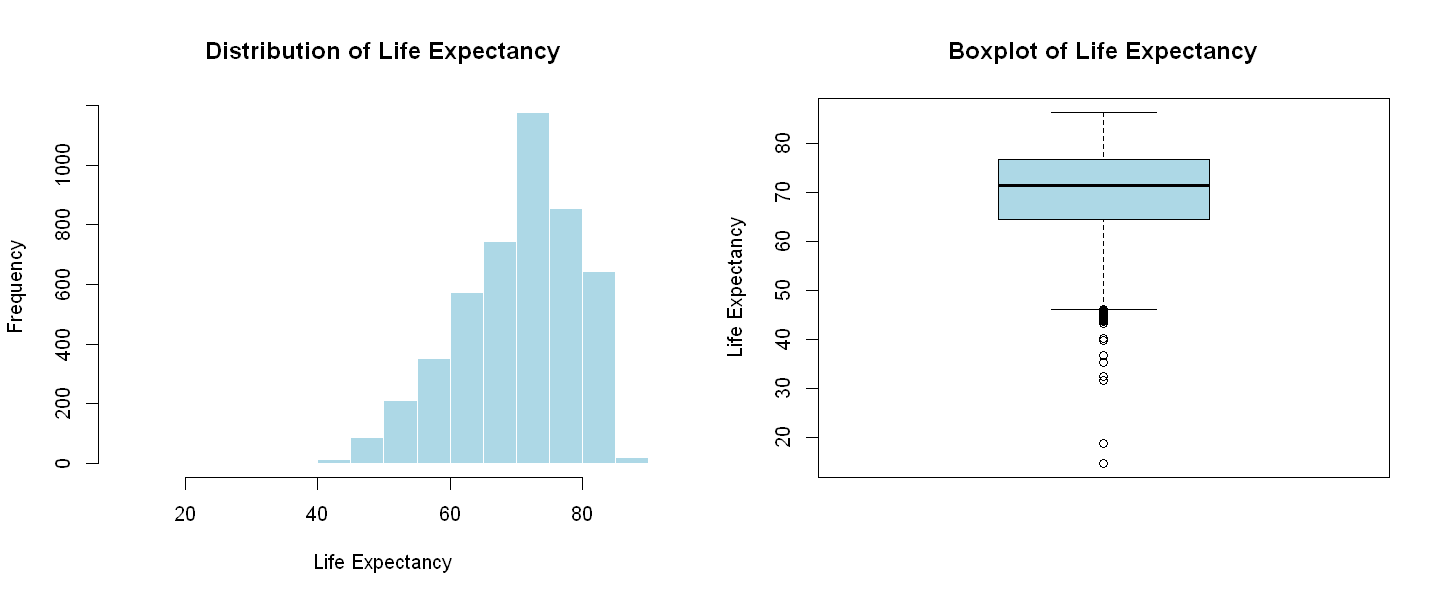

In [13]:
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1,2))

# Distribution of life expectancy (response)
hist(model_data$life_exp, main="Distribution of Life Expectancy", 
     xlab="Life Expectancy", col="Lightblue", border="white")

# Boxplot helps show outliers
boxplot(model_data$life_exp, main="Boxplot of Life Expectancy", 
        ylab="Life Expectancy", col="Lightblue")

# Summary statistics for the response
summary(model_data$life_exp)

The distribution of life expectancy is slightly left skewed, with most countries clustered between 65 and 80 years. The boxplot highlights several lower expectancy outliers. Summary statistics show a mean of approximately 70 years and a median of 71.5 years, with a wide overall range. These results suggest that while most countries have relatively high life expectancy, a few of the countries experience lower outcomes.

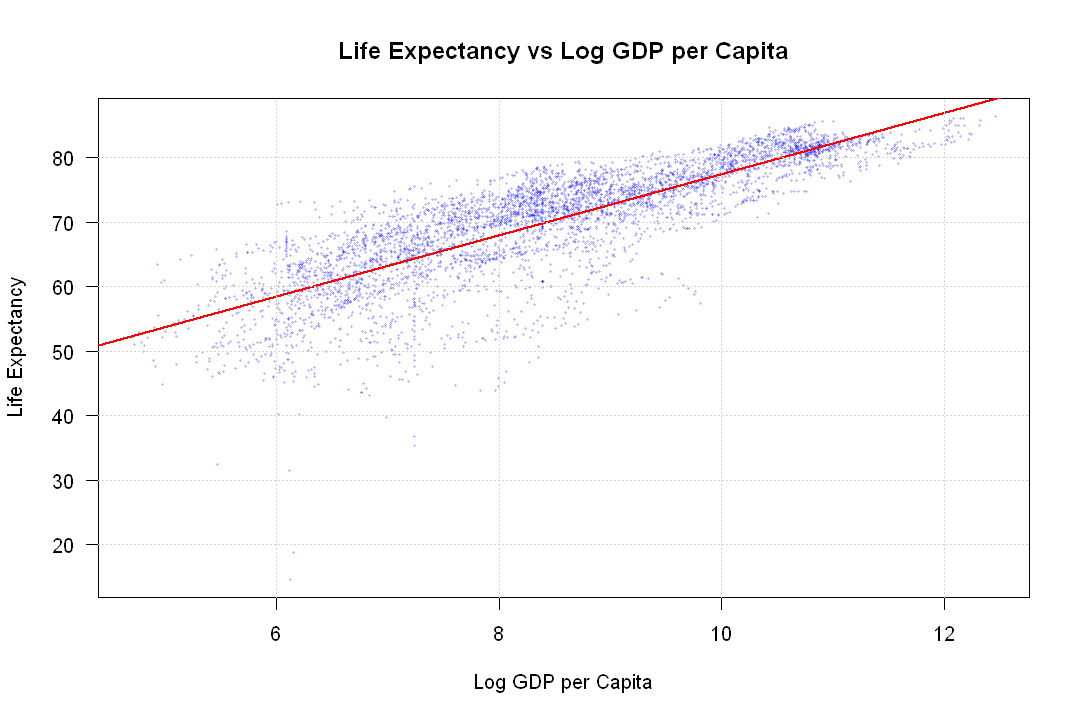

In [14]:
options(repr.plot.width = 9, repr.plot.height = 6)

# Life expectancy compared to income
plot(model_data$log_gdp, model_data$life_exp,
     
     main="Life Expectancy vs Log GDP per Capita",
     xlab="Log GDP per Capita",
     ylab="Life Expectancy",
     
     pch=16, cex=0.35, col=rgb(0, 0, 1, 0.25), las = 1)

abline(lm(life_exp ~ log_gdp, data=model_data), col="red", lwd = 2)

grid()

There is a clear positive relationship between log GDP per capita and life expectancy. Countries with higher income levels tend to have higher life expectancy. The relationship appears approximately linear after the log transformation, and greater variability is observed among lower income countries, while higher income countries are more clustered.

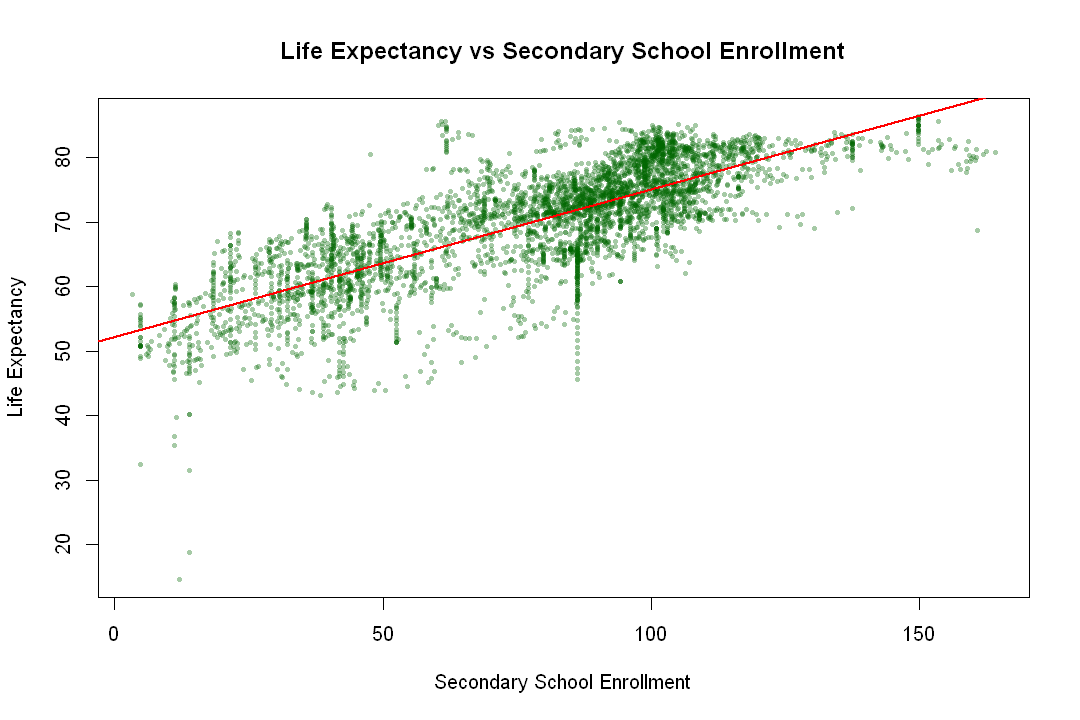

In [15]:
options(repr.plot.width = 9, repr.plot.height = 6)

# Life expectancy compared to education
plot(model_data$school_enrollment, model_data$life_exp, 
     
     main="Life Expectancy vs Secondary School Enrollment",
     xlab="Secondary School Enrollment", ylab="Life Expectancy",
     
     pch=16, cex=0.5, col=rgb(0,0.4,0,0.35))

abline(lm(life_exp ~ school_enrollment, data=model_data), col="red", lwd = 2)

There is a clear positive relationship between secondary school enrollment and life expectancy. Countries with higher enrollment rates tend to have higher life expectancy. The relationship appears approximately linear, and greater variability is observed at lower enrollment levels, while higher enrollment levels are more clustered.

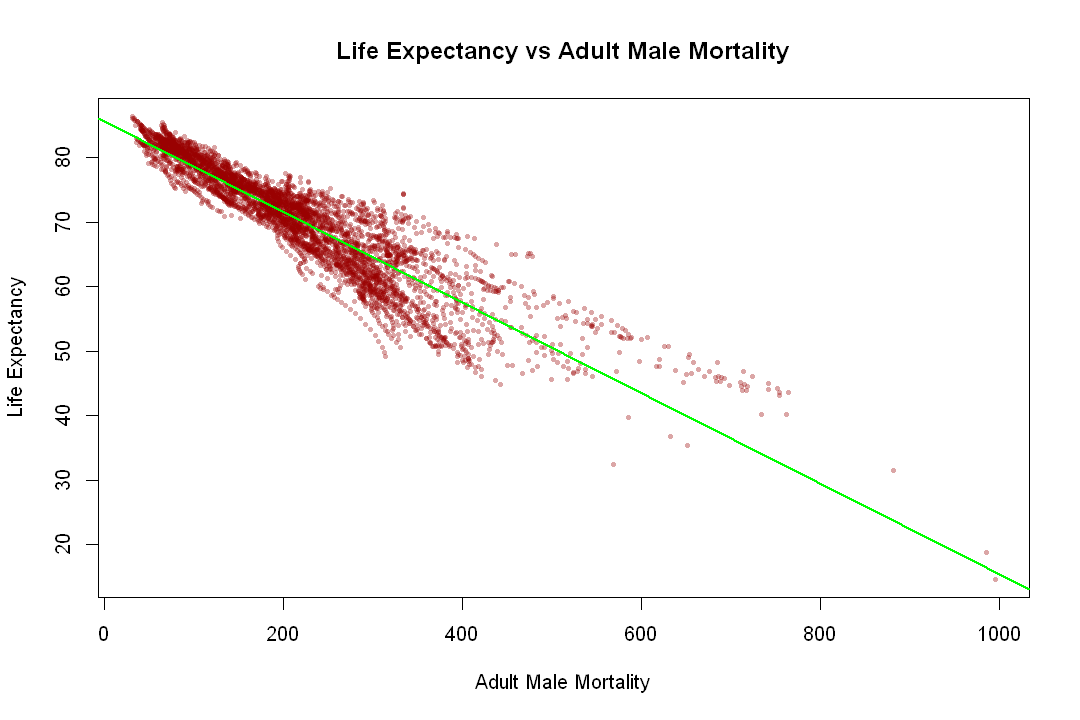

In [16]:
options(repr.plot.width = 9, repr.plot.height = 6)

# Life expectancy compared to adult mortality
plot(model_data$mort_adult_m, model_data$life_exp, 
     
     main="Life Expectancy vs Adult Male Mortality", 
     xlab="Adult Male Mortality", ylab="Life Expectancy", 
     
     pch=16, cex=0.5, col=rgb(0.6,0,0,0.35))

abline(lm(life_exp ~ mort_adult_m, data=model_data), col="green", lwd = 2)

There is a strong negative relationship between adult male mortality and life expectancy. Countries with higher adult mortality rates tend to have lower life expectancy. The relationship appears approximately linear, with higher mortality levels show greater variability and lower mortality levels are more clustered.

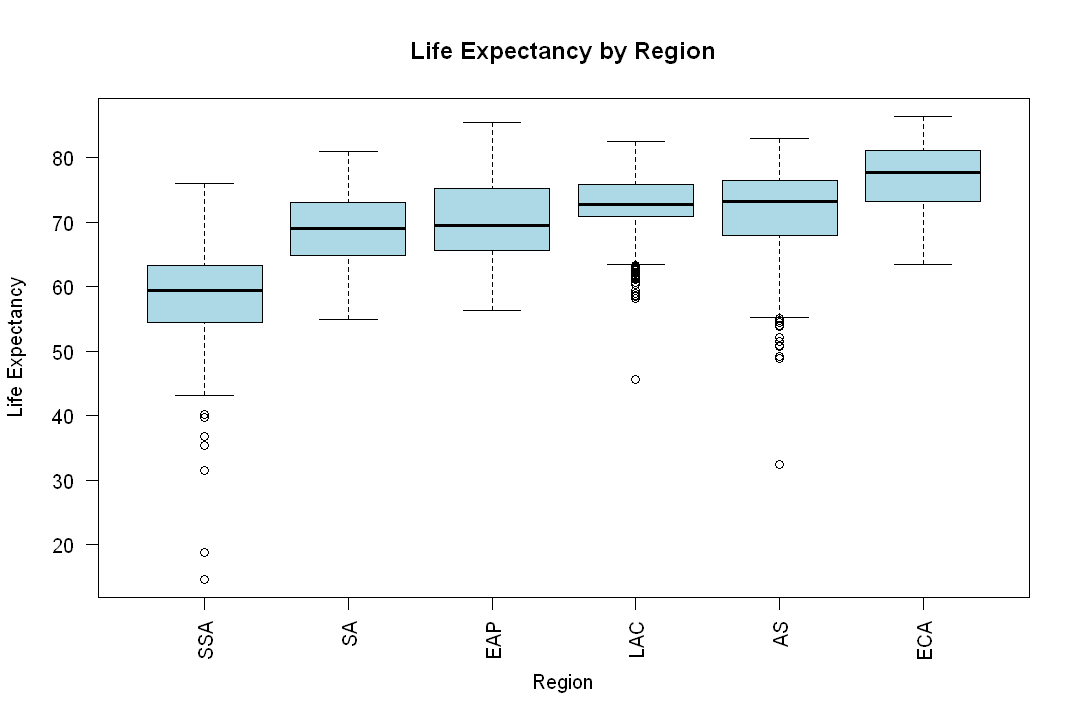

In [17]:
# Regional differences in life expectancy
model_data_boxplot <- model_data
model_data_boxplot$region <- reorder(model_data_boxplot$region, model_data_boxplot$life_exp, median, na.rm=TRUE)
boxplot(life_exp ~ region, data=model_data_boxplot,
        main="Life Expectancy by Region",
        xlab="Region", ylab="Life Expectancy", col="light blue",
        las = 2)

The boxplot shows variation in life expectancy across regions. Europe and Central Asia (ECA) has the highest median life expectancy, followed by Latin America (LAC) and East Asia and Pacific (EAP). South Asia (SA) and the Middle East (SAS) fall in the middle range, while Sub-Saharan Africa (SSA) has the lowest median and the widest spread.

SSA also exhibits the greatest variability and several low outliers, indicating significant disparities within the region. Higher performing regions such as ECA show more clustered distributions, suggesting more consistent life expectancy outcomes.

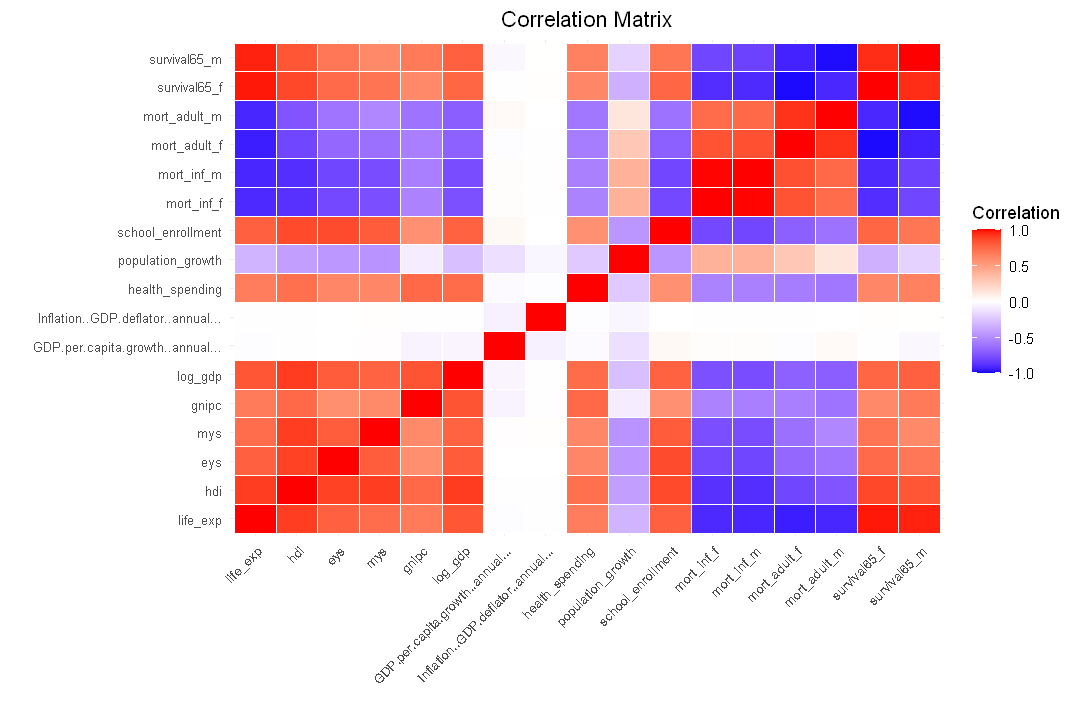

In [18]:
# Correlation matrix using ggplot
# Select numeric variables
correlation1 <- model_data %>% 
dplyr::select(where(is.numeric)) %>%
dplyr::select(-year)
correlation1 <- correlation1[, apply(correlation1, 2, var, na.rm=TRUE) !=0] # Remove variables with no variation

corr_mat <- cor(correlation1, use="complete.obs")
corr_mat[is.na(corr_mat)] <- 0

corr_df <- as.data.frame(as.table(corr_mat))
names(corr_df) <- c("Variable1", "Variable2", "Correlation")

ggplot(corr_df, aes(x=Variable1, y=Variable2, fill=Correlation)) +
    geom_tile(color="white") +
    scale_fill_gradient2(low="blue", high="red", mid="white", midpoint=0, limit= c(-1,1)) +
    labs(title="Correlation Matrix", x="", y="", fill="Correlation") +
    theme_minimal() +
    theme(axis.text.x=element_text(angle=45, hjust=1, size=8),
          axis.text.y=element_text(size=8),
          plot.title=element_text(hjust=0.5))

The correlation heatmap shows strong positive relationships between life expectancy and development indicators such as HDI, education, and income. Mortality variables are strongly negatively correlated with life expectancy and positively correlated with each other. These patterns suggest potential multicollinearity

___

## Base Model & Diagnostics

In [19]:
base_model <- lm(life_exp ~ hdi + eys + mys + log_gdp + 
                 GDP.per.capita.growth..annual... + Inflation..GDP.deflator..annual... +
                 health_spending + population_growth + school_enrollment +
                 mort_inf_f + mort_inf_m + mort_adult_f + mort_adult_m +
                 survival65_f + survival65_m, data=model_data)


vif_df <- data.frame(Variable=names(vif(base_model)), VIF=vif(base_model)) %>%
arrange(desc(VIF))

vif_df
summary(base_model)

,Variable,VIF
,<chr>,<dbl>
survival65_f,survival65_f,451.831281
mort_adult_f,mort_adult_f,288.943534
survival65_m,survival65_m,260.765699
mort_inf_m,mort_inf_m,255.995839
mort_inf_f,mort_inf_f,224.415797
mort_adult_m,mort_adult_m,191.674910
hdi,hdi,37.954525
mys,mys,8.508357
log_gdp,log_gdp,8.145774



Call:
lm(formula = life_exp ~ hdi + eys + mys + log_gdp + GDP.per.capita.growth..annual... + 
    Inflation..GDP.deflator..annual... + health_spending + population_growth + 
    school_enrollment + mort_inf_f + mort_inf_m + mort_adult_f + 
    mort_adult_m + survival65_f + survival65_m, data = model_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-14.5990  -0.5050  -0.0606   0.4025   3.4843 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         9.113e+00  8.660e-01  10.524  < 2e-16 ***
hdi                                 2.577e-01  4.486e-01   0.575  0.56565    
eys                                 7.226e-02  9.097e-03   7.944 2.44e-15 ***
mys                                 5.392e-02  1.039e-02   5.191 2.19e-07 ***
log_gdp                             1.531e-01  2.150e-02   7.124 1.21e-12 ***
GDP.per.capita.growth..annual...    3.258e-03  2.142e-03   1.521  0.12845    
Inflation..GDP.deflator..an

### Initial Summary and VIF

I first ran a base model including all selected variables to see overall relationships with life expectancy.

The model has a very high R-squared (~0.992), which means it explains most of the variation in life expectancy. Most variables are statistically significant, so they do have some relationship with the response.

However, the VIF results show extremely high values for several variables, especially survival and mortality measures. This indicates strong multicollinearity, meaning many variables are overlapping and explaining the same thing.

I also included HDI along with education variables (eys, mys), which likely adds to the multicollinearity since HDI already captures similar information.

Overall, while the model fits well, the results are not reliable due to multicollinearity. We'll need to reduce variables further and improve model stability.

In [20]:
cooks_d <- cooks.distance(base_model)
threshold <- 4 / nrow(model_data)
outliers <- which(cooks_d > threshold)
high_outliers <- which(cooks_d > 4*mean(cooks_d))
cat("Outliers:", length(outliers),"\n")
cat("High Outliers:", length(high_outliers),"\n")

Outliers: 250 
High Outliers: 24 


### Outlier Screening with Cook’s Distance

I used Cook’s Distance to identify observations that may have a large influence on the regression model. Using the common threshold of 4 / n, 250 observations were flagged. Since removing all 250 would remove many valid country-year observations, I used a stricter rule and only removed observations with Cook’s Distance greater than 4 * mean(cooks_d).

This resulted in 24 high influence observations being removed. This approach is more conservative because it removes only the most extreme influential points while keeping most of the country-level variation in the dataset.

In [21]:
model_data_clean <- model_data[-high_outliers, ]

clean_model <- lm(life_exp ~ hdi + eys + mys +log_gdp +
                  GDP.per.capita.growth..annual... + Inflation..GDP.deflator..annual... +
                  health_spending + population_growth + school_enrollment +
                  mort_inf_f + mort_inf_m + mort_adult_f + mort_adult_m +
                  survival65_f + survival65_m,
                  data=model_data_clean)

summary(clean_model)


Call:
lm(formula = life_exp ~ hdi + eys + mys + log_gdp + GDP.per.capita.growth..annual... + 
    Inflation..GDP.deflator..annual... + health_spending + population_growth + 
    school_enrollment + mort_inf_f + mort_inf_m + mort_adult_f + 
    mort_adult_m + survival65_f + survival65_m, data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.2523 -0.4735 -0.0494  0.3910  2.9310 

Coefficients:
                                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         2.371e+00  8.227e-01   2.882 0.003975 ** 
hdi                                 1.476e+00  4.277e-01   3.450 0.000566 ***
eys                                 5.763e-02  8.356e-03   6.897 6.03e-12 ***
mys                                 4.782e-02  9.414e-03   5.080 3.93e-07 ***
log_gdp                             8.362e-02  1.995e-02   4.192 2.82e-05 ***
GDP.per.capita.growth..annual...    3.627e-03  1.987e-03   1.825 0.067991 .  
Inflation..GDP.deflator..annual

After removing the 24 high-influence observations, I refit the regression model. The cleaned model still has a very strong fit, with an adjusted R-squared of about 0.993, meaning the predictors explain most of the variation in life expectancy.

Most predictors remain statistically significant, including HDI, schooling variables, log GDP, health spending, mortality rates, and survival rates. This suggests that development, education, income, and health outcomes are all strongly related to life expectancy.

However, some coefficient signs are still not fully intuitive, especially because mortality and survival variables are highly related to each other. This suggests that multicollinearity is still affecting interpretation, so the next step should be variable selection as mentioned before.

___

### Additional Diagnostics

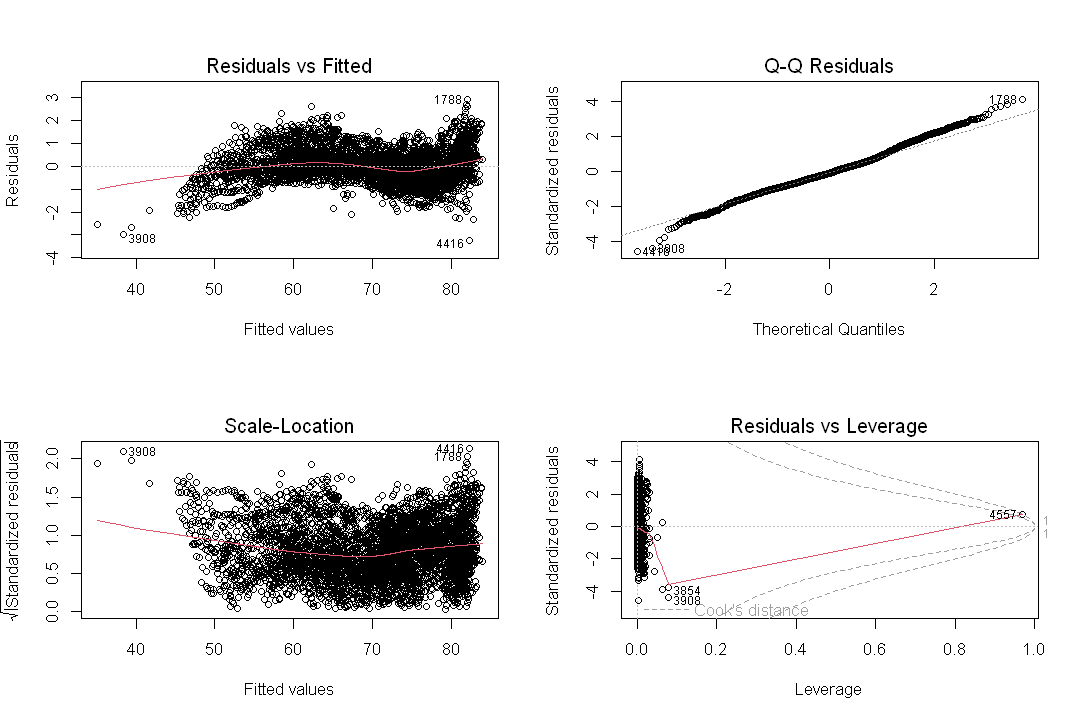

In [22]:
suppressWarnings({par(mfrow=c(2,2))
                  plot(clean_model)})

#### Residuals vs Fitted:
The residuals are mostly centered around zero, but there is some curvature in the pattern. This suggests that the relationship may not be perfectly linear and that some nonlinear effects could exist.

#### Q-Q Plot:
The points mostly follow the straight line, indicating that the residuals are approximately normally distributed. There are small deviations at the tails, but these are not severe and are common in real-world data.

#### Scale-Location Plot:
The spread of the residuals is not completely constant across fitted values. There is some increase in spread at higher fitted values, which suggests mild heteroskedasticity. However, the pattern is not extreme.

#### Residuals vs Leverage:
Most observations have low leverage, and only a few points stand out. The most extreme influential observations were already removed using Cook’s Distance, so remaining points do not appear to overly distort the model.

In [23]:
coeftest(clean_model, vcov=vcovHC(clean_model, type="HC1"))


t test of coefficients:

                                      Estimate  Std. Error t value  Pr(>|t|)
(Intercept)                         2.3706e+00  1.2308e+00  1.9261 0.0541509
hdi                                 1.4757e+00  6.1236e-01  2.4099 0.0159948
eys                                 5.7630e-02  1.0187e-02  5.6570 1.633e-08
mys                                 4.7820e-02  1.0436e-02  4.5824 4.718e-06
log_gdp                             8.3621e-02  2.5962e-02  3.2209 0.0012866
GDP.per.capita.growth..annual...    3.6273e-03  2.0078e-03  1.8066 0.0708898
Inflation..GDP.deflator..annual... -2.9473e-05  7.7433e-06 -3.8062 0.0001429
health_spending                     3.9434e-04  6.1552e-05  6.4066 1.635e-10
population_growth                  -2.9769e-02  1.0281e-02 -2.8956 0.0038023
school_enrollment                  -3.8694e-03  8.0974e-04 -4.7786 1.819e-06
mort_inf_f                         -6.1392e-02  1.0496e-02 -5.8492 5.279e-09
mort_inf_m                          3.0748e-02  8.

#### Robust Standard Errors

After applying robust standard errors, most variables remain statistically significant. This strengthens the analysis because it shows that the main relationships are still significant even after correcting for heteroskedasticity.

A few variables become weaker, such as GDP growth, but the major predictors remain important.

### Removing variables with high multicollinearity

In [24]:
reduced_model <- lm(life_exp ~ eys + mys + log_gdp + GDP.per.capita.growth..annual... +
                    health_spending + population_growth + school_enrollment + mort_adult_f + 
                    mort_inf_f, data=model_data_clean)
summary(reduced_model)


Call:
lm(formula = life_exp ~ eys + mys + log_gdp + GDP.per.capita.growth..annual... + 
    health_spending + population_growth + school_enrollment + 
    mort_adult_f + mort_inf_f, data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.2077 -0.9607 -0.0246  0.9625  6.7438 

Coefficients:
                                   Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                      69.3390016  0.2778482  249.557  < 2e-16 ***
eys                               0.1474971  0.0162670    9.067  < 2e-16 ***
mys                              -0.1029887  0.0142555   -7.224 5.85e-13 ***
log_gdp                           1.0018316  0.0329934   30.365  < 2e-16 ***
GDP.per.capita.growth..annual... -0.0102410  0.0043925   -2.331   0.0198 *  
health_spending                   0.0019286  0.0001162   16.597  < 2e-16 ***
population_growth                 0.0741156  0.0176571    4.197 2.75e-05 ***
school_enrollment                 0.0003682  0.0016987    0.217   0

In [25]:
vif_df_reduced <- data.frame(Variable=names(vif(reduced_model)), VIF=vif(reduced_model)) %>%
dplyr::arrange(desc(VIF))
vif_df_reduced

,Variable,VIF
,<chr>,<dbl>
mort_inf_f,mort_inf_f,5.815635
eys,eys,5.161098
school_enrollment,school_enrollment,4.880552
log_gdp,log_gdp,4.752855
mys,mys,4.010968
mort_adult_f,mort_adult_f,3.530868
health_spending,health_spending,2.381854
population_growth,population_growth,1.455213
GDP.per.capita.growth..annual...,GDP.per.capita.growth..annual...,1.036203


The VIF values in the reduced model are significantly lower than before. All variables now have VIF values below approximately 6, which indicates that multicollinearity is no longer a major issue.

In [26]:
# Variable selection using stepwise AIC
step_model <- stepAIC(reduced_model, direction= "both", trace=FALSE)
summary(step_model)


Call:
lm(formula = life_exp ~ eys + mys + log_gdp + GDP.per.capita.growth..annual... + 
    health_spending + population_growth + mort_adult_f + mort_inf_f, 
    data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.2081 -0.9599 -0.0259  0.9621  6.7442 

Coefficients:
                                   Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                      69.3382934  0.2778005  249.597  < 2e-16 ***
eys                               0.1490162  0.0146788   10.152  < 2e-16 ***
mys                              -0.1022684  0.0138614   -7.378 1.89e-13 ***
log_gdp                           1.0028108  0.0326794   30.686  < 2e-16 ***
GDP.per.capita.growth..annual... -0.0101887  0.0043854   -2.323   0.0202 *  
health_spending                   0.0019264  0.0001157   16.646  < 2e-16 ***
population_growth                 0.0736941  0.0175479    4.200 2.72e-05 ***
mort_adult_f                     -0.0461589  0.0004128 -111.810  < 2e-16 ***
mort_inf_f

In [27]:
# Compare reduced model vs selected model
AIC(reduced_model, step_model)
BIC(reduced_model, step_model)

,df,AIC
,<dbl>,<dbl>
reduced_model,11,17522.44
step_model,10,17520.49


,df,BIC
,<dbl>,<dbl>
reduced_model,11,17593.35
step_model,10,17584.95


I applied stepwise regression using AIC to refine the reduced model. The procedure removed school_enrollment, indicating that it did not add meaningful explanatory power once other variables (like years of schooling and GDP) were already included.

The final model includes education (eys, mys), economic factors (log_gdp, GDP growth), health spending, population growth, and mortality variables. The model has a strong fit, with an adjusted R-squared of about 0.967, meaning it explains most of the variation in life expectancy even after simplifying.

Both AIC and BIC decreased compared to the reduced model. This means the stepwise model achieves a better balance between fit and simplicity by removing unnecessary variables.

All remaining variables in the stepwise model are statistically significant at conventional levels (most with p-values < 0.001). This indicates strong evidence that these variables are related to life expectancy.

- Education variables (eys, mys) are significant, showing schooling is an important factor.
- Log GDP and GDP growth are significant, indicating economic conditions matter.
- Health spending is significant, suggesting better healthcare investment improves life expectancy.
- Mortality variables are highly significant and have strong effects, which is expected since they directly relate to health outcomes.
- Population growth is also significant, though its effect is smaller.

Overall, the low p-values suggest that the relationships observed in the model are unlikely to be due to random chance.

In [28]:
# Check multicollinearity after selection
vif_df_step <- data.frame(Variable=names(vif(step_model)), VIF=vif(step_model)) %>%
dplyr::arrange(desc(VIF))
vif_df_step

,Variable,VIF
,<chr>,<dbl>
mort_inf_f,mort_inf_f,5.780910
log_gdp,log_gdp,4.663775
eys,eys,4.203394
mys,mys,3.793024
mort_adult_f,mort_adult_f,3.457735
health_spending,health_spending,2.362541
population_growth,population_growth,1.437572
GDP.per.capita.growth..annual...,GDP.per.capita.growth..annual...,1.033073


The VIF values are all below approximately 6, indicating that multicollinearity is no longer a major issue. Compared to earlier models, this is a significant improvement, and the predictors now provide more independent information.

In [29]:
train_control <- trainControl(method="cv", number=5)
cv_model <- train(formula(step_model), data=model_data_clean, method="lm", trControl=train_control)
cv_model

Linear Regression 

4656 samples
   8 predictor

No pre-processing
Resampling: Cross-Validated (5 fold) 
Summary of sample sizes: 3725, 3725, 3725, 3724, 3725 
Resampling results:

  RMSE      Rsquared   MAE     
  1.587108  0.9673762  1.217216

Tuning parameter 'intercept' was held constant at a value of TRUE

Cross-validation results show an RMSE of approximately 1.6 and an R-squared of about 0.967, indicating strong predictive performance. The consistency between cross-validated and training results suggests that the model generalizes well and is not overfitting.

## Human Capital Model

In [30]:
human_model <- lm(life_exp ~ eys + mys + school_enrollment + health_spending +
                  mort_inf_f + mort_adult_f, data=model_data_clean)
summary(human_model)


Call:
lm(formula = life_exp ~ eys + mys + school_enrollment + health_spending + 
    mort_inf_f + mort_adult_f, data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5415 -1.0767 -0.0438  0.9526  7.9663 

Coefficients:
                    Estimate Std. Error  t value Pr(>|t|)    
(Intercept)       75.7501795  0.2172251  348.717  < 2e-16 ***
eys                0.2392061  0.0175997   13.592  < 2e-16 ***
mys               -0.0426906  0.0152800   -2.794  0.00523 ** 
school_enrollment  0.0052284  0.0018606    2.810  0.00497 ** 
health_spending    0.0036276  0.0001153   31.461  < 2e-16 ***
mort_inf_f        -0.1179330  0.0027119  -43.487  < 2e-16 ***
mort_adult_f      -0.0469820  0.0004614 -101.815  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.763 on 4649 degrees of freedom
Multiple R-squared:  0.9598,	Adjusted R-squared:  0.9597 
F-statistic: 1.848e+04 on 6 and 4649 DF,  p-value: < 2.2e-16


In [31]:
vif_df_human <- data.frame(Variable = names(vif(human_model)), VIF = vif(human_model)) %>%
dplyr::arrange(desc(VIF))
vif_df_human

,Variable,VIF
,<chr>,<dbl>
mort_inf_f,mort_inf_f,5.620495
eys,eys,4.891445
school_enrollment,school_enrollment,4.740825
mys,mys,3.731039
mort_adult_f,mort_adult_f,3.496970
health_spending,health_spending,1.898704


The human capital model focuses on education and health variables. The results show that schooling and health spending are positively associated with life expectancy, while mortality variables are negatively associated. The model has strong explanatory power, though slightly lower than the full model.

## Economic Model

In [32]:
economic_model <- lm(life_exp ~ log_gdp + GDP.per.capita.growth..annual... +
                     population_growth, data = model_data_clean)
summary(economic_model)


Call:
lm(formula = life_exp ~ log_gdp + GDP.per.capita.growth..annual... + 
    population_growth, data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-33.426  -2.294   0.698   3.245  13.483 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      32.68172    0.44500  73.443   <2e-16 ***
log_gdp                           4.53306    0.04882  92.845   <2e-16 ***
GDP.per.capita.growth..annual...  0.01522    0.01351   1.126     0.26    
population_growth                -0.60984    0.04762 -12.807   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.901 on 4652 degrees of freedom
Multiple R-squared:  0.6888,	Adjusted R-squared:  0.6886 
F-statistic:  3432 on 3 and 4652 DF,  p-value: < 2.2e-16


In [33]:
vif_df_econ <- data.frame(Variable = names(vif(economic_model)), VIF = vif(economic_model)) %>%
dplyr::arrange(desc(VIF))
vif_df_econ

,Variable,VIF
,<chr>,<dbl>
population_growth,population_growth,1.108922
log_gdp,log_gdp,1.090549
GDP.per.capita.growth..annual...,GDP.per.capita.growth..annual...,1.027681


The economic model examines income and macroeconomic factors. Log GDP is strongly positively associated with life expectancy, while growth and population effects are smaller. The model explains less variation than the full model, showing that economic factors alone are not sufficient.

## Final Model

In [34]:
final_model <- step_model
summary(final_model)


Call:
lm(formula = life_exp ~ eys + mys + log_gdp + GDP.per.capita.growth..annual... + 
    health_spending + population_growth + mort_adult_f + mort_inf_f, 
    data = model_data_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.2081 -0.9599 -0.0259  0.9621  6.7442 

Coefficients:
                                   Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                      69.3382934  0.2778005  249.597  < 2e-16 ***
eys                               0.1490162  0.0146788   10.152  < 2e-16 ***
mys                              -0.1022684  0.0138614   -7.378 1.89e-13 ***
log_gdp                           1.0028108  0.0326794   30.686  < 2e-16 ***
GDP.per.capita.growth..annual... -0.0101887  0.0043854   -2.323   0.0202 *  
health_spending                   0.0019264  0.0001157   16.646  < 2e-16 ***
population_growth                 0.0736941  0.0175479    4.200 2.72e-05 ***
mort_adult_f                     -0.0461589  0.0004128 -111.810  < 2e-16 ***
mort_inf_f

In [35]:
vif_df_final <- data.frame(Variable=names(vif(final_model)), VIF=vif(final_model)) %>%
dplyr::arrange(desc(VIF))
vif_df_final

,Variable,VIF
,<chr>,<dbl>
mort_inf_f,mort_inf_f,5.780910
log_gdp,log_gdp,4.663775
eys,eys,4.203394
mys,mys,3.793024
mort_adult_f,mort_adult_f,3.457735
health_spending,health_spending,2.362541
population_growth,population_growth,1.437572
GDP.per.capita.growth..annual...,GDP.per.capita.growth..annual...,1.033073


##### The final model is based on the stepwise selection results. It includes variables related to education (eys, mys), economic conditions (log_gdp, GDP growth), health spending, population growth, and mortality.

##### The model achieves an adjusted R-squared of approximately 0.967, indicating strong explanatory power. All variables are statistically significant, suggesting meaningful relationships with life expectancy.

##### Multicollinearity has been reduced, with all VIF values below acceptable thresholds, making the model more stable and interpretable.

##### Cross-validation was performed using 5-fold validation. The model achieved an RMSE of approximately 1.6 and an R-squared of about 0.967.

##### These results indicate strong predictive performance. The similarity between training and validation results suggests that the model generalizes well and is not overfitting.

___

## Predicted vs Actual Plot - Final Model

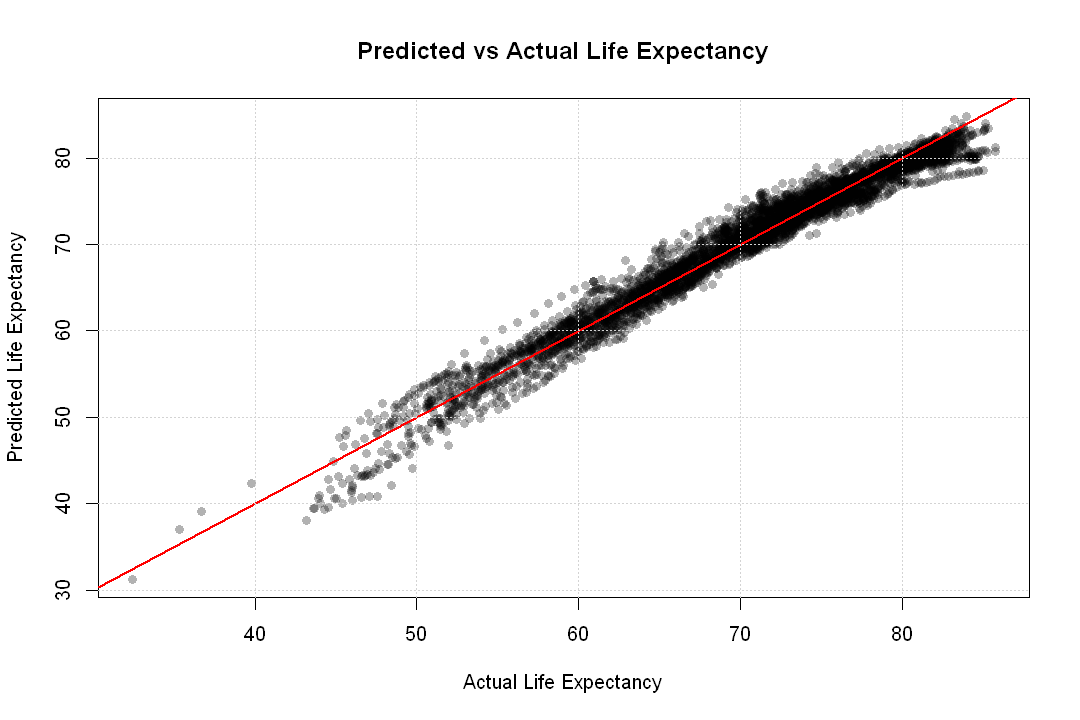

In [37]:
pred <- predict(final_model)
plot(model_data_clean$life_exp, pred,
     pch=16, col=rgb(0,0,0,0.3),
     xla="Actual Life Expectancy",
     ylab="Predicted Life Expectancy",
     main="Predicted vs Actual Life Expectancy")

abline(0, 1, col="red", lwd = 2)
grid()

The predicted vs actual plot shows how closely the model’s predictions match the observed life expectancy values. Most points lie very close to the 45-degree line, indicating that the model produces accurate predictions across countries. There is slightly more spread at lower life expectancy levels, suggesting the model is less precise for lower-income or higher-mortality countries. Overall, the tight clustering around the line confirms strong model fit and high predictive accuracy

## Residuals vs Fitted Plot - Final Model

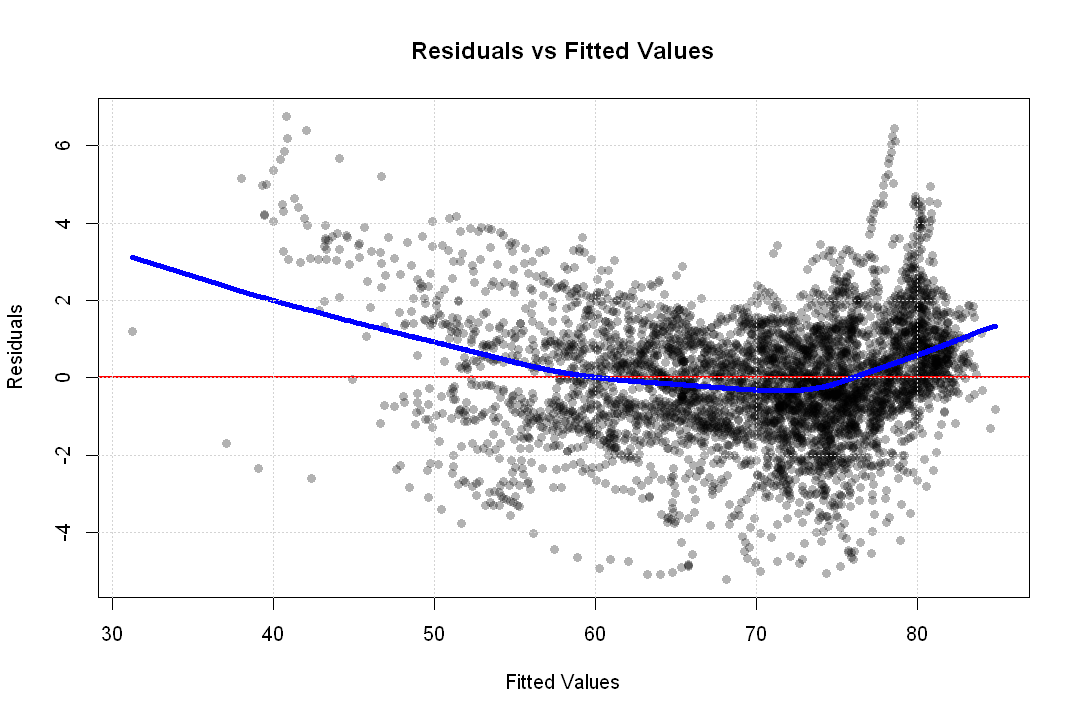

In [38]:
plot(final_model$fitted.values, resid(final_model),
     pch=16, col=rgb(0,0,0,0.3),
     xlab="Fitted Values",
     ylab="Residuals",
     main="Residuals vs Fitted Values")

abline(h=0, col="red", lwd = 2)
lines(lowess(final_model$fitted.values, resid(final_model)), col="blue", lwd = 4)

grid()

The residuals vs fitted plot is used to assess model assumptions. The residuals are generally centered around zero, which supports the linearity assumption. However, there is some visible curvature and increasing spread at higher fitted values, indicating mild heteroskedasticity, which could be addressed in further analyses

## Key Findings
- Higher education levels are associated with higher life expectancy
- Higher GDP is associated with improved health outcomes
- Health spending has a positive effect
- Mortality rates have strong negative effects
- Population growth has a smaller but significant impact

## Summary of Analysis


This analysis investigates the main factors influencing life expectancy using a panel dataset constructed from WHO, World Bank, and UNDP data. The initial regression model showed very strong explanatory power but also revealed high multicollinearity, particularly among mortality, survival, and HDI-related variables, which made interpretation less reliable.

To address this, influential observations were identified using Cook’s Distance and a small number of extreme outliers were removed. The model was then simplified by eliminating redundant variables, which reduced multicollinearity to acceptable levels. Stepwise AIC was applied to further refine the model, resulting in a more parsimonious specification without a significant loss in fit.

The final model explains a large proportion of the variation in life expectancy (adjusted R² ≈ 0.967), and cross-validation results (RMSE ≈ 1.6) indicate that the model generalizes well to new data.

Overall, the results show that higher levels of education and income are associated with increased life expectancy, while higher mortality rates are strongly associated with lower life expectancy. Health spending also has a positive and statistically significant effect, and population growth shows a smaller but meaningful relationship.

In conclusion, life expectancy appears to be driven by a combination of economic development, education, and health outcomes, with mortality variables having the strongest influence in the model.